In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import geopandas as gpd
import celltypist
import decoupler as dc
from scipy.io import mmread
from sklearn.utils import sparsefuncs
import scipy.sparse as sp
import celltypist
from celltypist import models

In [3]:
sample = "Pat03_W0"
um = '008'

print ("Reading in segmentation for sample " + sample)
data_directory = "../segmentation/" + sample + "/"
adata = anndata.read_h5ad(data_directory + sample + "_" + um + ".h5ad")
adata

Reading in segmentation for sample Pat03_W0


AnnData object with n_obs × n_vars = 6721 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

In [4]:
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=10)

#remove cells with high mitochondrial content
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.05, :]

#remove mitochondrial genes
adata = adata[:, [gene for gene in adata.var_names if not gene.startswith('MT-')]]
adata

View of AnnData object with n_obs × n_vars = 4187 × 11713
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

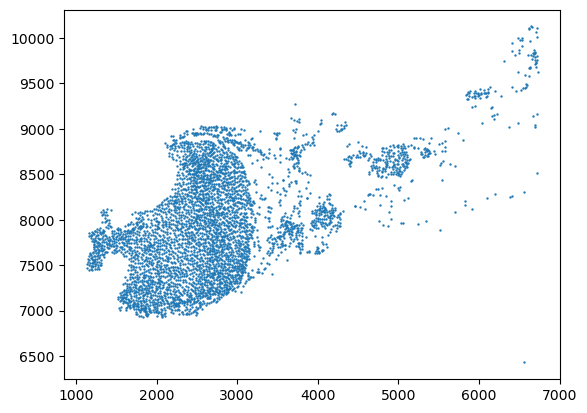

In [5]:
plt.scatter(adata.obsm["spatial"][:,0], adata.obsm["spatial"][:,1], s=0.5)

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

2025-03-20 14:09:44.650135: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 14:09:44.670451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 14:09:44.695281: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-20 14:09:44.703178: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-20 14:09:44.722050: I tensorflow/core/platform/cpu_feature_guar

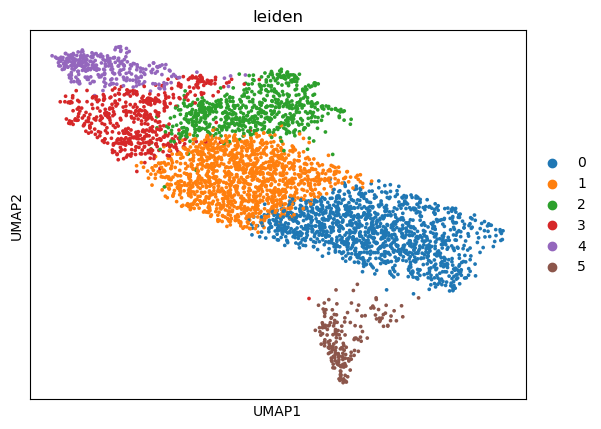

In [7]:
# PCA
sc.tl.pca(adata)
# Compute nearest neighbors
sc.pp.neighbors(adata)
# UMAP for visualization
sc.tl.umap(adata)
# Clustering
sc.tl.leiden(adata, resolution=0.6)  
# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

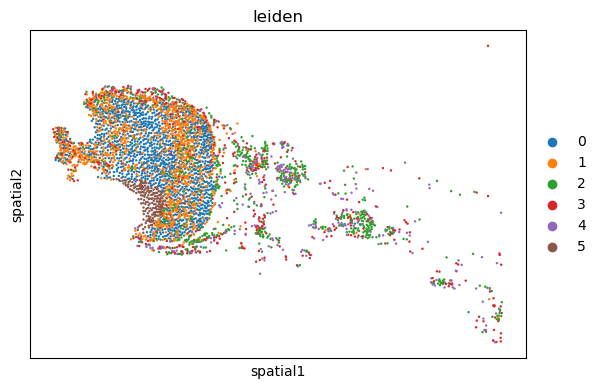

In [8]:
sc.pl.spatial(adata, color='leiden', spot_size=30, alpha_img=1)

In [9]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

In [10]:
adata.obs["leiden"].value_counts()

0    1288
1    1240
2     663
3     503
4     307
5     186
Name: leiden, dtype: int64

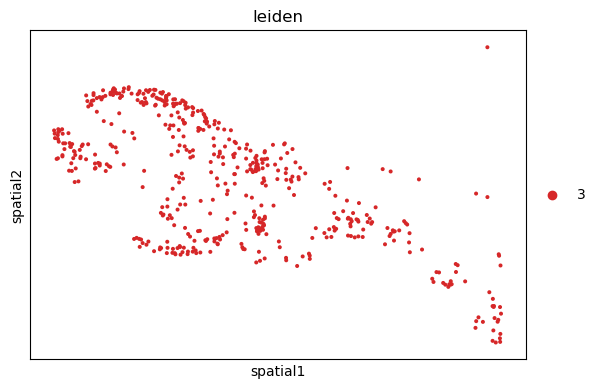

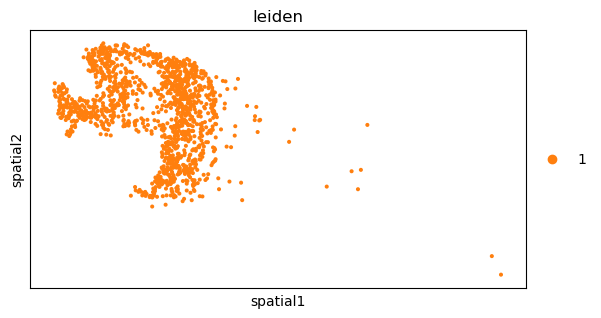

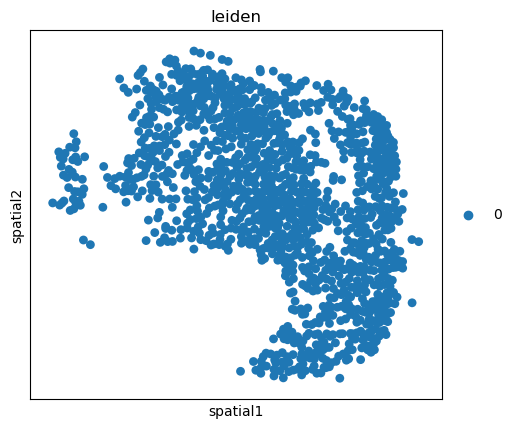

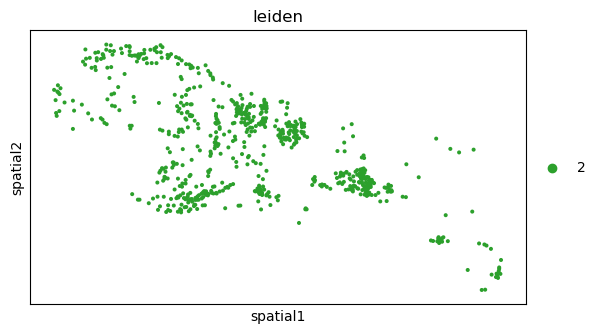

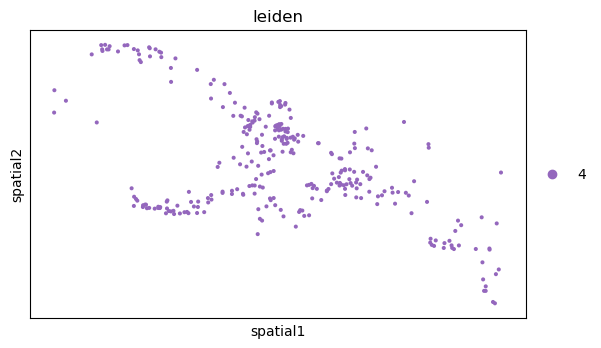

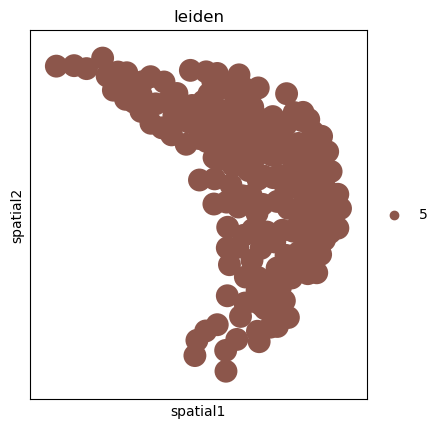

In [11]:
for cell_type in adata.obs["leiden"].unique():
    sc.pl.spatial(adata[adata.obs["leiden"] == cell_type], color='leiden', spot_size=50, alpha_img=1)

In [12]:
clusters = adata.obs['leiden'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': adata.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][cluster]
    })
    #only include positive logfoldchanges
    cluster_results = cluster_results[cluster_results['logfoldchanges'] > 0]
    de_results[cluster] = cluster_results

#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster 3
        gene  logfoldchanges     pvals  pvals_adj
0        ELN        1.308573  0.704343   0.961376
1      HMCN2        2.845911  0.761889   0.961376
2      ARAP3        2.497836  0.773392   0.961376
3      PDE2A        1.687964  0.837519   0.961376
4   ANKRD33B        2.312713  0.840362   0.961376
5      ADH1B        2.157090  0.848133   0.961376
6        CLU        0.933919  0.856196   0.961376
7      PROCR        1.563059  0.879108   0.961376
8      MYH11        0.836459  0.881403   0.961376
9      LYVE1        1.713538  0.882334   0.961376
10      HBA2        2.237644  0.889725   0.961376
11     TACR1        2.026642  0.897499   0.961376
12    ALS2CL        2.026538  0.897561   0.961376
13     VPS29        1.342743  0.899055   0.961376
14    THSD7A        1.420273  0.905532   0.961376
15      RBP5        1.418463  0.909989   0.961376
16     GNG11        1.436543  0.910051   0.961376
17    MANSC1        1.600681  0.920877   0.961376
18     INKA1        1.528090  0.920908  

In [13]:
tumor_clusters = ['5']
#create new adata without for the TME
tme = adata[~adata.obs['leiden'].isin(tumor_clusters)].copy()
tme

AnnData object with n_obs × n_vars = 4001 × 11713
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [14]:
models.download_models()

📂 Storing models in /home/fceccarelli/.celltypist/data/models
⏩ Skipping [1/52]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/52]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/52]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/52]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/52]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/52]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/52]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/52]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/52]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [10/52]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [11/52]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [12/52]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [13/52]: Autopsy_COVID19_Lung.pkl (file exists)
⏩ Skipping [14/52]: COVID19_HumanChallenge_Blood.pkl (file exists)
⏩ Skipping [15/52]: COVID19_Immune_Landscape.pkl (file exists)
⏩ Skipping [16/52]: Cells_Adul

In [15]:
model = models.Model.load(model = 'Immune_All_High.pkl')
model.cell_types

array(['B cells', 'B-cell lineage', 'Cycling cells', 'DC', 'DC precursor',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ETP',
       'Early MK', 'Endothelial cells', 'Epithelial cells',
       'Erythrocytes', 'Erythroid', 'Fibroblasts', 'Granulocytes',
       'HSC/MPP', 'ILC', 'ILC precursor', 'MNP', 'Macrophages',
       'Mast cells', 'Megakaryocyte precursor',
       'Megakaryocytes/platelets', 'Mono-mac', 'Monocyte precursor',
       'Monocytes', 'Myelocytes', 'Plasma cells', 'Promyelocytes',
       'T cells', 'pDC', 'pDC precursor'], dtype=object)

In [16]:
predictions = celltypist.annotate(tme, model = model, majority_voting = True)

🔬 Input data has 4001 cells and 11713 genes
🔗 Matching reference genes in the model
🧬 4084 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [17]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
ID_11302,Plasma cells,35,B cells
ID_11303,Macrophages,11,T cells
ID_11304,Macrophages,1,Macrophages
ID_11305,Plasma cells,6,B cells
ID_11307,Macrophages,32,B cells
...,...,...,...
ID_31438,B cells,45,B cells
ID_31476,Plasma cells,3,B cells
ID_31481,B cells,6,B cells
ID_31555,B cells,0,T cells


In [18]:
tme = predictions.to_adata()

In [19]:
tme.obs["majority_voting"].value_counts()

Macrophages          2085
B cells              1412
T cells               409
Endothelial cells      95
Name: majority_voting, dtype: int64

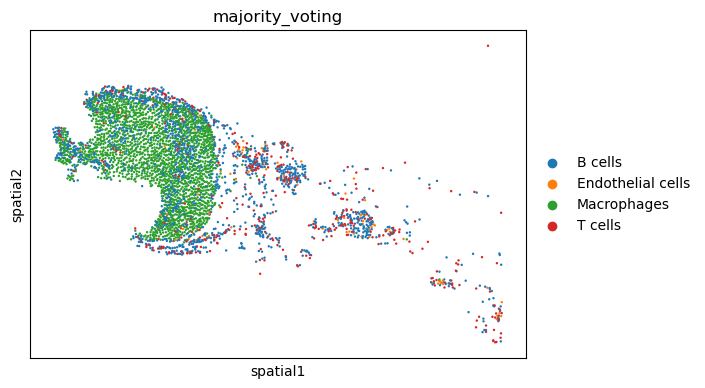

In [20]:
sc.pl.spatial(tme, color='majority_voting', spot_size=30, alpha_img=0)

In [ ]:
# if 'Macrophage' not in tme.obs['majority_voting'].cat.categories:
#     tme.obs['majority_voting'] = tme.obs['majority_voting'].cat.add_categories(['Macrophage'])

# # Step 2: Perform the replacement
# tme.obs['majority_voting'] = tme.obs['majority_voting'].replace(regex=r'.*macrophages.*', value='Macrophages')
# tme.obs['majority_voting'] = tme.obs['majority_voting'].cat.remove_unused_categories()

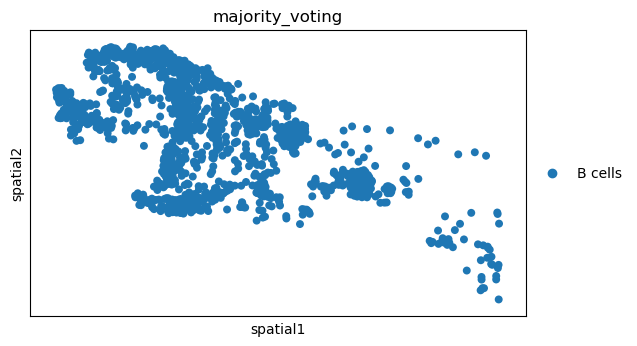

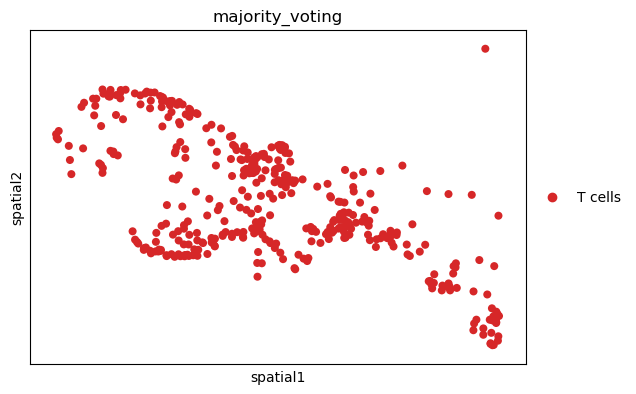

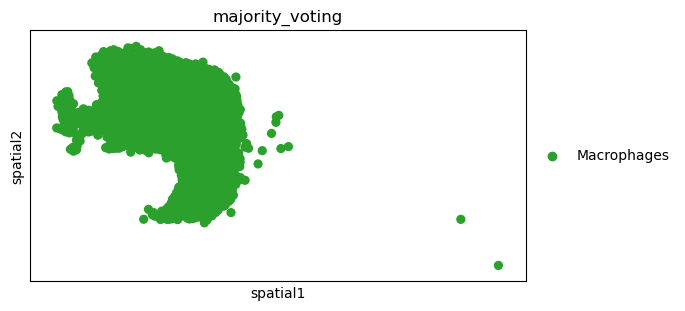

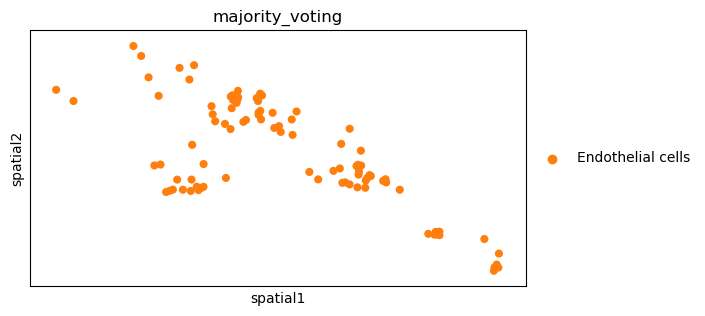

In [21]:
#spatiall plot each cell type
for cell_type in tme.obs["majority_voting"].unique():
    sc.pl.spatial(tme[tme.obs["majority_voting"] == cell_type], color='majority_voting', spot_size=100, alpha_img=0)

In [22]:
#find DE genes for each cluster
sc.tl.rank_genes_groups(tme, 'majority_voting', method='wilcoxon')

In [23]:
clusters = tme.obs['majority_voting'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': tme.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': tme.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': tme.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': tme.uns['rank_genes_groups']['pvals_adj'][cluster]
    })
    
    # Filter for positively expressed genes
    de_results[cluster] = cluster_results

In [24]:
#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster B cells
        gene  logfoldchanges     pvals  pvals_adj
0       IGKC        0.884264  0.000873   0.020679
1      MYH11        1.751539  0.619099   0.976762
2      CCL21        2.534589  0.802391   0.976762
3      IGLC1        1.682237  0.820525   0.976762
4     THSD7A        1.854228  0.844894   0.976762
5       PRCD        1.579216  0.862923   0.976762
6     ERRFI1        1.342464  0.880979   0.976762
7      HMCN2        1.536438  0.887479   0.976762
8     SORBS1        1.644736  0.889674   0.976762
9       TIE1        1.510341  0.892153   0.976762
10   SIGLEC6        1.406838  0.896706   0.976762
11    COL4A5        4.363503  0.898043   0.976762
12    SCARA3        1.459821  0.903212   0.976762
13     IGHA1        1.388549  0.908159   0.976762
14     ADIRF        0.538656  0.909374   0.976762
15     PRRT2        1.183594  0.910452   0.976762
16    PKNOX2       23.385160  0.911440   0.976762
17     TTLL7        1.537028  0.919063   0.976762
18     PROCR        0.868470  0.92

In [25]:
#write the results to a file
#with open(data_directory + sample + "_de_results.txt", 'w') as f:
#    for cluster, results in de_results.items():
#        f.write(f"Cluster {cluster}\n")
#        f.write(results.head(50).to_string())
#        f.write("\n\n")

In [26]:
tme.obs["cell_type"] = tme.obs["majority_voting"]

In [27]:
adata.obs.loc[tme.obs.index, 'cell_type'] = tme.obs['cell_type']

In [28]:
if 'cell_type' not in adata.obs:
    adata.obs['cell_type'] = pd.Categorical([None] * len(adata.obs))

# Step 2: Add 'Melanocytes' to the categories if not already present
if 'Melanocytes' not in adata.obs['cell_type'].cat.categories:
    adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['Melanocytes'])

# Step 3: Assign 'Melanocytes' to clusters 0 and 1
adata.obs.loc[adata.obs['leiden'].isin(tumor_clusters), 'cell_type'] = "Melanocytes"

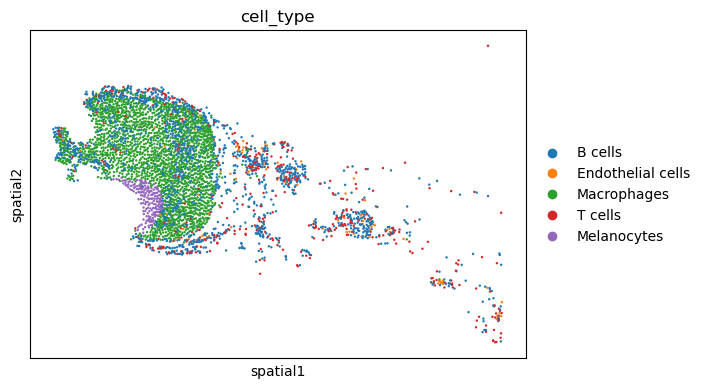

In [29]:
sc.pl.spatial(adata, color='cell_type', spot_size=30, alpha_img=1)

... storing 'cell_annotation' as categorical


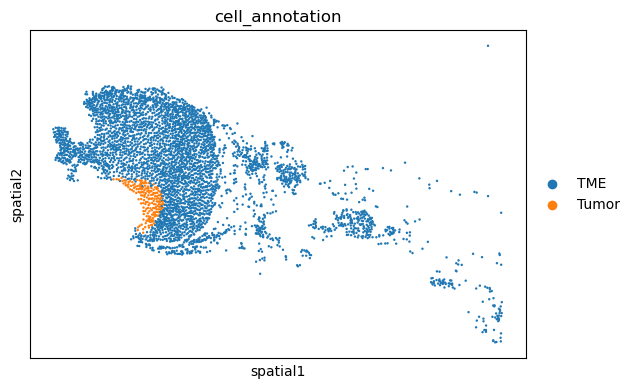

In [30]:
adata.obs["cell_annotation"] = np.where(
    adata.obs["cell_type"] == "Melanocytes", "Tumor", "TME")
sc.pl.spatial(adata, color='cell_annotation', spot_size=30, alpha_img=1)

In [31]:
adata.write(data_directory + sample + "_" + um + "_processed.h5ad")